# Bài tập: Phân loại Spam Email bằng Gaussian Naive Bayes
* **Họ tên:** [Điền họ tên của bạn]
* **MSSV:** [Điền MSSV của bạn]


## 1. Thiết làm môi trường và Import thư viện


In [19]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')


## 2. Tải và Khám phá dữ liệu (EDA)


--- 5 DÒNG ĐẦU DỮ LIỆU ---


,Unnamed: 0,label,text,label_num
0,605,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,2349,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,3624,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0
3,4685,spam,"Subject: photoshop , windows , office . cheap ...",1
4,2030,ham,Subject: re : indian springs\r\nthis deal is t...,0



--- THÔNG TIN DỮ LIỆU ---
<class 'pandas.DataFrame'>
RangeIndex: 5171 entries, 0 to 5170
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  5171 non-null   int64
 1   label       5171 non-null   str  
 2   text        5171 non-null   str  
 3   label_num   5171 non-null   int64
dtypes: int64(2), str(2)
memory usage: 161.7 KB

--- THỐNG KÊ CHI TIẾT NHÃN ---
Số lượng:
label
ham     3672
spam    1499
Name: count, dtype: int64

Tỉ lệ phần trăm:
label
ham     71.01141
spam    28.98859
Name: proportion, dtype: float64


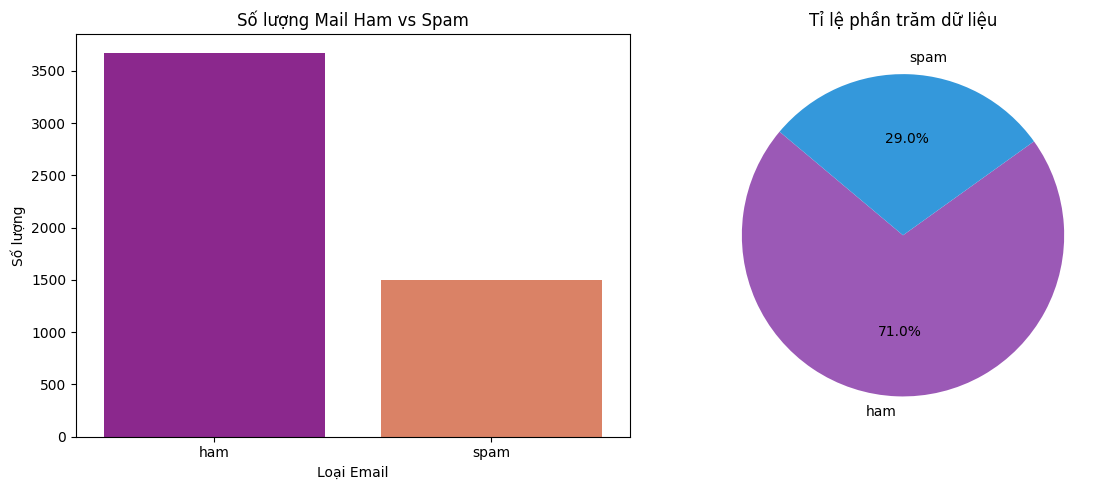

In [20]:
# Tải tập dữ liệu từ file local CSV
df = pd.read_csv('spam_ham_dataset.csv')

# Xem 5 dòng đầu
print('--- 5 DÒNG ĐẦU DỮ LIỆU ---')
display(df.head())

# Thông tin dữ liệu
print('\n--- THÔNG TIN DỮ LIỆU ---')
df.info()

# Thống kê nhãn
counts = df['label'].value_counts()
percent = df['label'].value_counts(normalize=True) * 100
print('\n--- THỐNG KÊ CHI TIẾT NHÃN ---')
print(f'Số lượng:\n{counts}')
print(f'\nTỉ lệ phần trăm:\n{percent}')

# Vẽ biểu đồ phân bố nhãn
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=df, x='label', palette='plasma')
plt.title('Số lượng Mail Ham vs Spam')
plt.xlabel('Loại Email')
plt.ylabel('Số lượng')

plt.subplot(1, 2, 2)
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140, colors=['#9b59b6', '#3498db'])
plt.title('Tỉ lệ phần trăm dữ liệu')
plt.tight_layout()
plt.show()


## 3. Tiền xử lý dữ liệu (Preprocessing)


In [21]:
# Xóa bỏ dữ liệu trống nếu có
df = df.dropna()

# Ánh xạ nhãn: spam -> 1, ham -> 0
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})

# Tách tập Test gốc (20%) độc lập
df_train_full, df_test = train_test_split(df, test_size=0.2, random_state=42)

# Downsampling tập Train để chỉ giữ 35% Spam
df_spam_train = df_train_full[df_train_full['label_num'] == 1]
df_ham_train = df_train_full[df_train_full['label_num'] == 0]

n_spam = len(df_spam_train)
n_ham_needed = int((n_spam / 0.35) - n_spam)
df_ham_train_down = df_ham_train.sample(n=min(n_ham_needed, len(df_ham_train)), random_state=42)

# Gộp lại thành tập huấn luyện chính thức
df_train_final = pd.concat([df_spam_train, df_ham_train_down]).sample(frac=1, random_state=42)

X_train_raw = df_train_final['text'].astype(str).values
y_train = df_train_final['label_num'].values

# Vector hóa văn bản với giới hạn 1000 features để tránh hiện tượng thưa hóa quá mức ở NB
vectorizer = TfidfVectorizer(max_features=1000)
X_train = vectorizer.fit_transform(X_train_raw).toarray()
print(f'Kích thước dữ liệu huấn luyện sau vector hóa: {X_train.shape}')


Kích thước dữ liệu huấn luyện sau vector hóa: (3445, 1000)


## 4. Xây dựng và Huấn luyện mô hình


Đang huấn luyện mô hình và ghi nhận tiến trình học...
Bước 1/10: Quy mô dữ liệu 10% -> Độ chính xác: 97.97%
Bước 2/10: Quy mô dữ liệu 20% -> Độ chính xác: 95.94%
Bước 3/10: Quy mô dữ liệu 30% -> Độ chính xác: 95.45%
Bước 4/10: Quy mô dữ liệu 40% -> Độ chính xác: 94.99%
Bước 5/10: Quy mô dữ liệu 50% -> Độ chính xác: 94.19%
Bước 6/10: Quy mô dữ liệu 60% -> Độ chính xác: 93.90%
Bước 7/10: Quy mô dữ liệu 70% -> Độ chính xác: 93.61%
Bước 8/10: Quy mô dữ liệu 80% -> Độ chính xác: 93.61%
Bước 9/10: Quy mô dữ liệu 90% -> Độ chính xác: 93.42%
Bước 10/10: Quy mô dữ liệu 100% -> Độ chính xác: 93.24%
Huấn luyện GaussianNB chính thức hoàn thành!


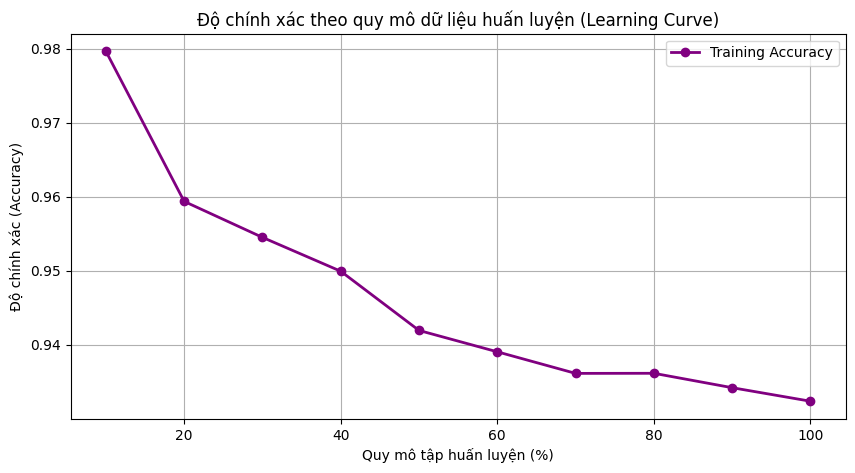

Đã lưu thành công tại: gaussian_nb_model.pkl


In [22]:
class GaussianNB_Scratch:
    def __init__(self, smoothing=1e-2):
        self.classes = None
        self.mean = None
        self.var = None
        self.priors = None
        self.smoothing = smoothing
        self.history = [] # Lưu độ chính xác tích lũy theo lượng dữ liệu

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.classes = np.unique(y)
        n_classes = len(self.classes)

        self.mean = np.zeros((n_classes, n_features), dtype=np.float64)
        self.var = np.zeros((n_classes, n_features), dtype=np.float64)
        self.priors = np.zeros(n_classes, dtype=np.float64)

        for idx, c in enumerate(self.classes):
            X_c = X[y == c]
            self.mean[idx, :] = X_c.mean(axis=0)
            # Bổ sung tham số smoothing (0.01) để tối ưu hóa sự phân bố thưa của TF-IDF
            self.var[idx, :] = X_c.var(axis=0) + self.smoothing
            self.priors[idx] = X_c.shape[0] / float(n_samples)

    def _pdf(self, class_idx, x):
        mean = self.mean[class_idx]
        var = self.var[class_idx]
        numerator = np.exp(-((x - mean) ** 2) / (2 * var))
        denominator = np.sqrt(2 * np.pi * var)
        return numerator / denominator

    def predict(self, X):
        y_pred = [self._predict_single(x) for x in X]
        return np.array(y_pred)

    def _predict_single(self, x):
        posteriors = []
        for idx, c in enumerate(self.classes):
            prior = np.log(self.priors[idx])
            conditional = np.sum(np.log(self._pdf(idx, x) + 1e-9))
            posterior = prior + conditional
            posteriors.append(posterior)
        return self.classes[np.argmax(posteriors)]

# Khởi tạo mô hình với smoothing tối ưu = 0.01
model = GaussianNB_Scratch(smoothing=1e-2)

# Vẽ đường cong học tập (Learning Curve) qua 10 phân đoạn dữ liệu
print('Đang huấn luyện mô hình và ghi nhận tiến trình học...')
steps = np.linspace(0.1, 1.0, 10)
for i, step in enumerate(steps):
    size = int(step * len(X_train))
    X_sub, y_sub = X_train[:size], y_train[:size]
    
    step_model = GaussianNB_Scratch(smoothing=1e-2)
    step_model.fit(X_sub, y_sub)
    
    y_sub_pred = step_model.predict(X_sub)
    acc = np.mean(y_sub_pred == y_sub)
    model.history.append(acc)
    print(f'Bước {i+1}/10: Quy mô dữ liệu {step*100:.0f}% -> Độ chính xác: {acc*100:.2f}%')

# Fit mô hình chính thức
model.fit(X_train, y_train)
print('Huấn luyện GaussianNB chính thức hoàn thành!')

# Vẽ biểu đồ
plt.figure(figsize=(10, 5))
plt.plot(steps * 100, model.history, marker='o', color='purple', linestyle='-', linewidth=2, label='Training Accuracy')
plt.title('Độ chính xác theo quy mô dữ liệu huấn luyện (Learning Curve)')
plt.xlabel('Quy mô tập huấn luyện (%)')
plt.ylabel('Độ chính xác (Accuracy)')
plt.grid(True)
plt.legend()
plt.show()

# Lưu trữ tham số mô hình
model_save = {
    'mean': model.mean,
    'var': model.var,
    'priors': model.priors,
    'classes': model.classes,
    'vocabulary': vectorizer.vocabulary_,
    'idf': vectorizer.idf_
}
filename = 'gaussian_nb_model.pkl'
with open(filename, 'wb') as f:
    pickle.dump(model_save, f)
print(f'Đã lưu thành công tại: {filename}')


## 5. Dự đoán và Đánh giá kết quả


Đang thực hiện dự đoán trên tập Test (vui lòng chờ)...
Độ chính xác (Accuracy) trên tập Test: 93.53%

Báo cáo phân loại chi tiết (Classification Report):
              precision    recall  f1-score   support

         Ham       0.99      0.92      0.95       742
        Spam       0.82      0.98      0.90       293

    accuracy                           0.94      1035
   macro avg       0.91      0.95      0.92      1035
weighted avg       0.94      0.94      0.94      1035



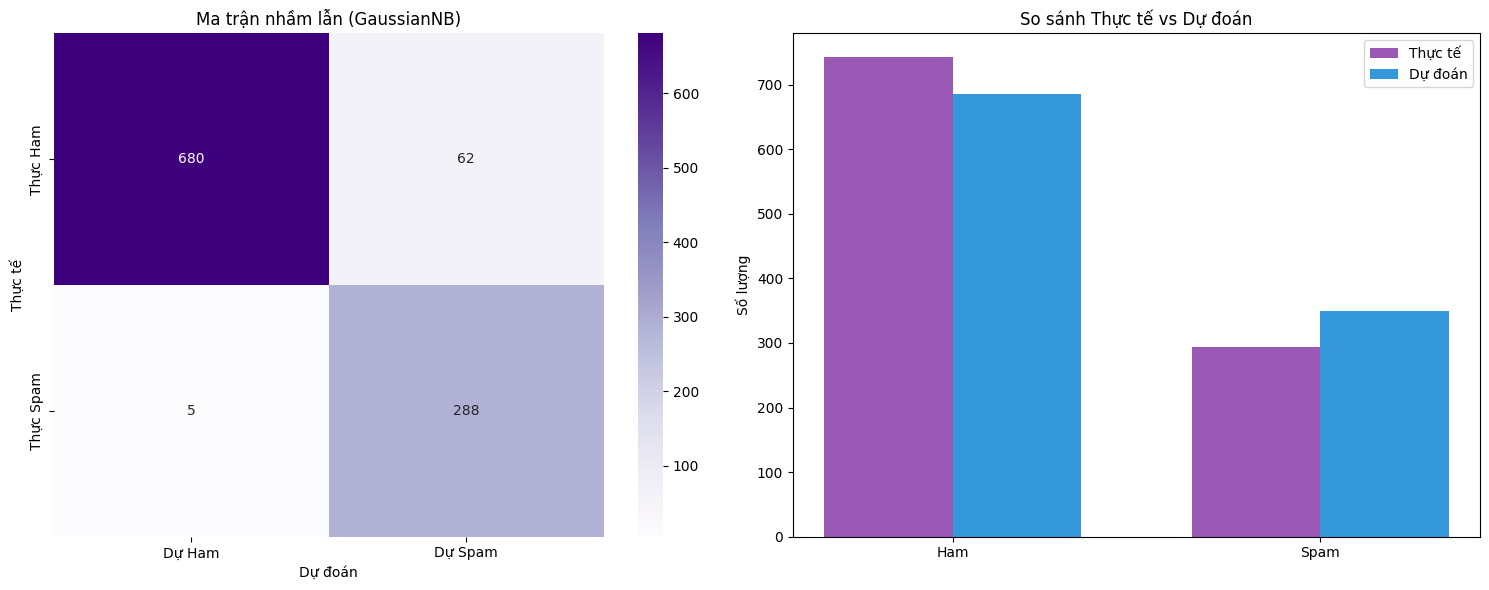

In [23]:
PATH_MODEL_PKL = 'gaussian_nb_model.pkl'
PATH_DATA_CSV = 'spam_ham_dataset.csv'

# Load mô hình
with open(PATH_MODEL_PKL, 'rb') as f:
    model_data = pickle.load(f)

mean = model_data['mean']
var = model_data['var']
priors = model_data['priors']
classes = model_data['classes']
vocab = model_data['vocabulary']
saved_idf = model_data['idf']

# Tách tập Test gốc
df = pd.read_csv(PATH_DATA_CSV)
df['label_num'] = df['label'].map({'spam': 1, 'ham': 0})
X_text = df['text'].astype(str).values
y = df['label_num'].values
_, X_test_raw, _, y_test = train_test_split(X_text, y, test_size=0.2, random_state=42)

# Tái tạo vectorizer
vectorizer = TfidfVectorizer(vocabulary=vocab)
vectorizer.idf_ = saved_idf
X_test = vectorizer.transform(X_test_raw).toarray()

def get_gaussian_log_pdf(class_idx, x):
    m = mean[class_idx]
    v = var[class_idx]
    return -0.5 * np.log(2 * np.pi * v) - 0.5 * ((x - m)**2 / v)

def predict_nb(X):
    predictions = []
    for x in X:
        posteriors = []
        for idx, c in enumerate(classes):
            prior = np.log(priors[idx])
            likelihood = np.sum(get_gaussian_log_pdf(idx, x))
            posterior = prior + likelihood
            posteriors.append(posterior)
        predictions.append(classes[np.argmax(posteriors)])
    return np.array(predictions)

print('Đang thực hiện dự đoán trên tập Test (vui lòng chờ)...')
y_pred = predict_nb(X_test)

# Đánh giá mô hình
acc = accuracy_score(y_test, y_pred)
print('='*50)
print(f'Độ chính xác (Accuracy) trên tập Test: {acc*100:.2f}%')
print('='*50)
print('\nBáo cáo phân loại chi tiết (Classification Report):')
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# Vẽ biểu đồ
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Dự Ham', 'Dự Spam'], yticklabels=['Thực Ham', 'Thực Spam'])
plt.title('Ma trận nhầm lẫn (GaussianNB)')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')

plt.subplot(1, 2, 2)
labels = ['Ham', 'Spam']
actual = [np.sum(y_test == 0), np.sum(y_test == 1)]
predicted = [np.sum(y_pred == 0), np.sum(y_pred == 1)]
x = np.arange(len(labels))
width = 0.35
plt.bar(x - width/2, actual, width, label='Thực tế', color='#9b59b6')
plt.bar(x + width/2, predicted, width, label='Dự đoán', color='#3498db')
plt.xticks(x, labels)
plt.ylabel('Số lượng')
plt.title('So sánh Thực tế vs Dự đoán')
plt.legend()
plt.tight_layout()
plt.show()


### Thử nghiệm dự đoán trên văn bản email mới


In [24]:
new_emails = [
    "Congratulations! You've won a free iPhone. Click here to claim your prize!",
    "We detected a new sign-in attempt to your account. Please confirm your identity below if this wasn't you."
]

print('--- DỰ ĐOÁN TRÊN VĂN BẢN TÙY Ý ---')
for text in new_emails:
    X_new = vectorizer.transform([text]).toarray()
    x_single = X_new[0]
    posteriors = []
    for idx, c in enumerate(classes):
        prior = np.log(priors[idx])
        likelihood = np.sum(get_gaussian_log_pdf(idx, x_single))
        posteriors.append(prior + likelihood)
    single_pred = classes[np.argmax(posteriors)]
    result = 'Spam' if single_pred == 1 else 'Ham'
    print(f'Văn bản: "{text}"')
    print(f'-> Dự đoán: {result}\n')


--- DỰ ĐOÁN TRÊN VĂN BẢN TÙY Ý ---
Văn bản: "Congratulations! You've won a free iPhone. Click here to claim your prize!"
-> Dự đoán: Spam

Văn bản: "We detected a new sign-in attempt to your account. Please confirm your identity below if this wasn't you."
-> Dự đoán: Spam

